## Pipeline tổng quan
---

1. Import thư viện
2. Load dữ liệu
3. Khám phá dữ liệu
4. Làm sạch dữ liệu
5. Tạo feature và biến đổi feature
6. Xây dựng và so sánh mô hình
7. Đánh giá mô hình
8. Chia dữ liệu train/test chuẩn
9. Lưu model và suy luận (trước tuning)
10. Chia dữ liệu cho luồng đánh giá bổ sung
11. Bảng so sánh metric Train/Test
12. Tinh chỉnh siêu tham số
13. Train XGBoost cho luồng đánh giá bổ sung

## 1. Import thư viện
---

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError('Chưa cài xgboost. Hãy chạy: pip install xgboost') from exc

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TARGET_COL = 'Diabetes'

### Nhận xét output

- Đã import đầy đủ thư viện cho preprocessing, modeling, tuning và đánh giá.
- Khai báo RANDOM_STATE và TARGET_COL ngay từ đầu để đảm bảo tái lập.

## 2. Load dữ liệu
---

In [2]:
candidate_paths = [
    Path('Data_diabetes.csv'),
    Path('DATN_1') / 'Data_diabetes.csv',
    Path.cwd() / 'Data_diabetes.csv',
    Path.cwd() / 'DATN_1' / 'Data_diabetes.csv',
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Không tìm thấy Data_diabetes.csv trong thư mục hiện tại hoặc DATN_1')

BASE_DIR = data_path.resolve().parent
ARTIFACT_DIR = BASE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(data_path, low_memory=False, encoding='latin-1')
print('Data path:', data_path.resolve())
print('Base dir:', BASE_DIR)
print('Shape:', data.shape)
data.head()

Data path: C:\Users\BSS GROUP\DATN_1\Data_diabetes.csv
Base dir: C:\Users\BSS GROUP\DATN_1
Shape: (12725, 75)


,V1,Tinh/Thanhpho,Quan/huyen,Xa/phuong,Ngay phong van,Ho ten,id,Dia chi,Gioi,Nam sinh,...,WHR_total,glucose,prediabetes2,std_wgt3,tccv,glucose2,fpg,dia,predia,fpgva
0,1785,32,1,4,40717.0,DANG THI THU HA,34.0,"TO 1, THACH THANG",2,1950,...,1,1,1,0.119252,0,1,1,0,1,0
1,1565,32,1,1,40733.0,LE THI THANH HUYEN,64.0,"TO 24, THANH BINH",2,1944,...,1,2,0,0.095826,0,2,2,1,0,0
2,460,32,1,3,40726.0,HA THUC HAI,210.0,"TO 36, BINH HIEN",1,1954,...,1,1,1,0.183041,0,1,1,0,1,0
3,1990,32,1,4,40721.0,HO THI GIAO,241.0,"TO 30, THACH THANG",2,1942,...,1,1,1,0.095826,0,1,1,0,1,0
4,978,32,2,3,40731.0,NGUYEN VAN VIEN,228.0,"TO 35, HOA KHE",1,1965,...,0,1,1,0.329838,0,1,1,0,1,0


### Nhận xét output

- Dữ liệu đã được đọc thành công.
- Kích thước bộ dữ liệu được in ra để xác nhận số dòng và số cột.

## 3. Khám phá dữ liệu
---

### Quan sát và khám phá tập dữ liệu

In [3]:
YEAR_COLLECTED = 2022

if 'Nam sinh' in data.columns:
    data['Tuoi'] = YEAR_COLLECTED - pd.to_numeric(data['Nam sinh'], errors='coerce')
    data = data.drop(columns=['Nam sinh'])

print('Đã tạo cột Tuổi và loại bỏ Năm sinh (nếu có).')
print('Shape hiện tại:', data.shape)
data.head()

Đã tạo cột Tuổi và loại bỏ Năm sinh (nếu có).
Shape hiện tại: (12725, 75)


,V1,Tinh/Thanhpho,Quan/huyen,Xa/phuong,Ngay phong van,Ho ten,id,Dia chi,Gioi,Dan toc,...,glucose,prediabetes2,std_wgt3,tccv,glucose2,fpg,dia,predia,fpgva,Tuoi
0,1785,32,1,4,40717.0,DANG THI THU HA,34.0,"TO 1, THACH THANG",2,1,...,1,1,0.119252,0,1,1,0,1,0,72
1,1565,32,1,1,40733.0,LE THI THANH HUYEN,64.0,"TO 24, THANH BINH",2,1,...,2,0,0.095826,0,2,2,1,0,0,78
2,460,32,1,3,40726.0,HA THUC HAI,210.0,"TO 36, BINH HIEN",1,1,...,1,1,0.183041,0,1,1,0,1,0,68
3,1990,32,1,4,40721.0,HO THI GIAO,241.0,"TO 30, THACH THANG",2,1,...,1,1,0.095826,0,1,1,0,1,0,80
4,978,32,2,3,40731.0,NGUYEN VAN VIEN,228.0,"TO 35, HOA KHE",1,1,...,1,1,0.329838,0,1,1,0,1,0,57


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12725 entries, 0 to 12724
Data columns (total 75 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   V1                                      12725 non-null  int64  
 1   Tinh/Thanhpho                           12725 non-null  int64  
 2   Quan/huyen                              12725 non-null  int64  
 3   Xa/phuong                               12725 non-null  int64  
 4   Ngay phong van                          12231 non-null  float64
 5   Ho ten                                  12725 non-null  str    
 6   id                                      12723 non-null  float64
 7   Dia chi                                 12724 non-null  str    
 8   Gioi                                    12725 non-null  int64  
 9   Dan toc                                 12725 non-null  int64  
 10  Tinh chat cong viec                     12725 non-null  int64  
 11  

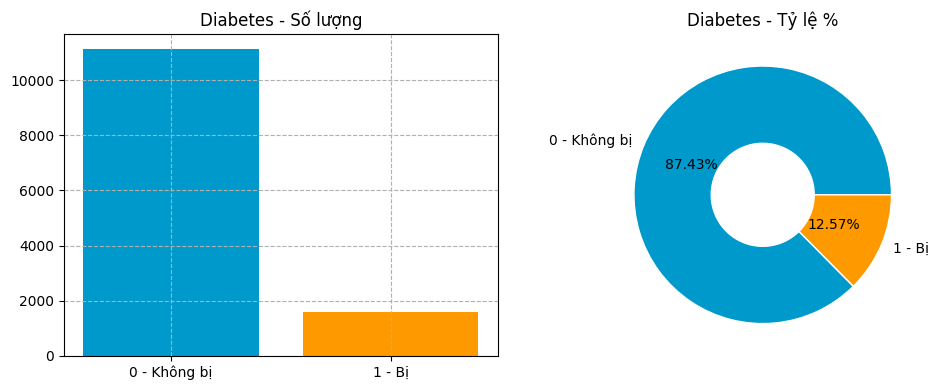

In [5]:
kq_diabetes = data[TARGET_COL].value_counts()
lb = ['0 - Không bị', '1 - Bị']

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(lb, kq_diabetes.values, color=['#0099CC', '#FF9900'])
plt.grid(ls='--')
plt.title('Diabetes - Số lượng')

plt.subplot(1, 2, 2)
plt.pie(
    kq_diabetes.values,
    labels=lb,
    colors=['#0099CC', '#FF9900'],
    autopct='%.2f%%',
    wedgeprops=dict(width=0.6, edgecolor='w')
)
plt.title('Diabetes - Tỷ lệ %')
plt.tight_layout()
plt.show()

### Nhận xét output

- Dữ liệu mất cân bằng lớp, cần theo dõi Recall và F1 bên cạnh Accuracy.
- Đây là cơ sở để dùng trọng số lớp trong XGBoost.

## 4. Làm sạch dữ liệu
---

### Xử lý dữ liệu thiếu, trùng lặp, kiểu dữ liệu và leakage

In [6]:
drop_cols = [
    'Glucose_class', 'Pre_diabete', 'predia',
    'glucose2', 'fpgva', 'fpg', 'glucose',
    'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h',
    'WHR_male', 'WHR_female', 'WHR_male2', 'WHR_female2', 'WHR_total',
    'obesity', 'khuvuc2', 'cvd',
    'Nam chuan doan tang huyet ap',
    'std_wgt1', 'std_wgt3',
    'Ho ten', 'Dia chi', 'Ngay phong van', 'Tinh/Thanhpho', 'Quan/huyen', 'Xa/phuong',
    'V1', 'id',
    'Diabetes_binary', 'dia', 'prediabetes2',
]

leakage_keywords = ['diab', 'predia', 'pre_diab', 'fpg', 'glucose', 'xet_nghiem_duong']
keyword_drop_cols = [
    c for c in data.columns
    if c != TARGET_COL and any(k in c.lower() for k in leakage_keywords)
]

all_drop_candidates = sorted(set(drop_cols + keyword_drop_cols))
existing_drop_cols = [c for c in all_drop_candidates if c in data.columns]
data = data.drop(columns=existing_drop_cols)

print('Số cột đã xóa:', len(existing_drop_cols))
print('Shape sau khi xóa cột:', data.shape)
print('Các giá trị trùng lặp:', data.duplicated().sum())

Số cột đã xóa: 30
Shape sau khi xóa cột: (12725, 45)
Các giá trị trùng lặp: 0


In [7]:
before = len(data)
data = data[~data[TARGET_COL].isna()].copy()
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors='coerce').astype(int)

for c in data.columns:
    if c == TARGET_COL:
        continue
    if data[c].dtype != 'O':
        data[c] = pd.to_numeric(data[c], errors='coerce')

after = len(data)
print('Rows trước/sau clean target:', before, after)
print('Tổng missing hiện tại (xử lý trong pipeline):', int(data.isna().sum().sum()))

Rows trước/sau clean target: 12725 12725
Tổng missing hiện tại (xử lý trong pipeline): 81270


### Nhận xét output

- Đã loại bỏ nhóm cột có nguy cơ leakage nghiệp vụ.
- Missing values được để pipeline xử lý sau khi split để tránh leakage.

## 5. Tạo feature và biến đổi feature
---

Mục tiêu: tạo các feature cộng hưởng có ý nghĩa để nâng cao khả năng dự đoán.

In [8]:
fe_data = data.copy()

for c in ['Tuoi', 'BMI', 'WHR', 'HATT_mean', 'HATTr_mean']:
    if c in fe_data.columns:
        fe_data[c] = pd.to_numeric(fe_data[c], errors='coerce')

if 'HATT_mean' in fe_data.columns and 'HATTr_mean' in fe_data.columns:
    fe_data['PulsePressure'] = fe_data['HATT_mean'] - fe_data['HATTr_mean']
    fe_data['MAP'] = (2 * fe_data['HATTr_mean'] + fe_data['HATT_mean']) / 3

def add_interaction(df, new_col, c1, c2):
    if c1 in df.columns and c2 in df.columns:
        df[new_col] = df[c1] * df[c2]

add_interaction(fe_data, 'Age_BMI', 'Tuoi', 'BMI')
add_interaction(fe_data, 'Age_WHR', 'Tuoi', 'WHR')

print('Số cột sau feature engineering:', fe_data.shape[1])

Số cột sau feature engineering: 49


## 6. Xây dựng và so sánh mô hình
---

In [9]:
base_df = data.copy()
valid_idx = base_df[~base_df[TARGET_COL].isna()].index
base_df = base_df.loc[valid_idx].copy()
fe_df = fe_data.loc[valid_idx].copy()

y = base_df[TARGET_COL].astype(int)
X_base = base_df.drop(columns=[TARGET_COL])
X_fe = fe_df.drop(columns=[TARGET_COL])

Xb_trainval, Xb_test, y_trainval, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Xb_train, Xb_val, y_train, y_val = train_test_split(
    Xb_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)

Xf_train = X_fe.loc[Xb_train.index]
Xf_val = X_fe.loc[Xb_val.index]
Xf_test = X_fe.loc[Xb_test.index]

print('Đã chuẩn bị xong dữ liệu cho baseline và feature-engineered (train/val/test)')
print(f'- Train: {Xb_train.shape}, Validation: {Xb_val.shape}, Test: {Xb_test.shape}')

Đã chuẩn bị xong dữ liệu cho baseline và feature-engineered (train/val/test)
- Train: (7635, 44), Validation: (2545, 44), Test: (2545, 44)


In [10]:
def get_scale_pos_weight(y_series):
    pos = int((y_series == 1).sum())
    neg = int((y_series == 0).sum())
    return max(1.0, neg / max(1, pos))

def build_xgb_pipeline(X_train, y_train):
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

    transformers = []
    if num_cols:
        transformers.append((
            'num',
            Pipeline([('imputer', SimpleImputer(strategy='median'))]),
            num_cols,
        ))
    if cat_cols:
        transformers.append((
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            cat_cols,
        ))

    scale_pos_weight = get_scale_pos_weight(y_train)

    return Pipeline([
        ('prep', ColumnTransformer(transformers=transformers)),
        ('model', XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            objective='binary:logistic',
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1
        ))
    ])

def evaluate_model(pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_prob),
    }
    return metrics, classification_report(y_test, y_pred), confusion_matrix(y_test, y_pred)

In [11]:
baseline_pipe = build_xgb_pipeline(Xb_train, y_train)
fe_pipe = build_xgb_pipeline(Xf_train, y_train)

baseline_metrics, baseline_report, baseline_cm = evaluate_model(
    baseline_pipe, Xb_train, Xb_val, y_train, y_val
)
fe_metrics, fe_report, fe_cm = evaluate_model(
    fe_pipe, Xf_train, Xf_val, y_train, y_val
)

baseline_train_metrics, _, _ = evaluate_model(
    build_xgb_pipeline(Xb_train, y_train), Xb_train, Xb_train, y_train, y_train
)
fe_train_metrics, _, _ = evaluate_model(
    build_xgb_pipeline(Xf_train, y_train), Xf_train, Xf_train, y_train, y_train
)

model_compare = pd.DataFrame([
    {
        'Model': 'Baseline',
        'F1_Train': baseline_train_metrics['F1'],
        'F1_Val': baseline_metrics['F1'],
        'F1_Gap': baseline_train_metrics['F1'] - baseline_metrics['F1'],
        'Recall_Val': baseline_metrics['Recall'],
        'Precision_Val': baseline_metrics['Precision'],
        'ROC_AUC_Val': baseline_metrics['ROC_AUC'],
    },
    {
        'Model': 'Feature_Engineered',
        'F1_Train': fe_train_metrics['F1'],
        'F1_Val': fe_metrics['F1'],
        'F1_Gap': fe_train_metrics['F1'] - fe_metrics['F1'],
        'Recall_Val': fe_metrics['Recall'],
        'Precision_Val': fe_metrics['Precision'],
        'ROC_AUC_Val': fe_metrics['ROC_AUC'],
    }
])

model_compare['SelectionScore'] = model_compare['F1_Val'] - model_compare['F1_Gap']
selected_row = model_compare.sort_values(['SelectionScore', 'F1_Val'], ascending=False).iloc[0]
selected_model_name = selected_row['Model']

if selected_model_name == 'Baseline':
    X_train_best, X_val_best, X_test_best = Xb_train, Xb_val, Xb_test
    selected_pipe = baseline_pipe
else:
    X_train_best, X_val_best, X_test_best = Xf_train, Xf_val, Xf_test
    selected_pipe = fe_pipe

print('Mô hình được chọn (quy tắc chống overfitting):', selected_model_name)
model_compare.round(4)

Mô hình được chọn (quy tắc chống overfitting): Baseline


,Model,F1_Train,F1_Val,F1_Gap,Recall_Val,Precision_Val,ROC_AUC_Val,SelectionScore
0,Baseline,0.5748,0.3118,0.2630,0.4906,0.2285,0.6842,0.0488
1,Feature_Engineered,0.5942,0.2900,0.3042,0.4500,0.2140,0.6727,-0.0141


### Nhận xét output

- Mô hình được chọn theo SelectionScore = F1_Val - F1_Gap để cân bằng hiệu năng và tổng quát hóa.
- Bạn cập nhật số liệu thực tế sau khi chạy cell để hoàn thiện phần báo cáo.

## 7. Đánh giá mô hình
---

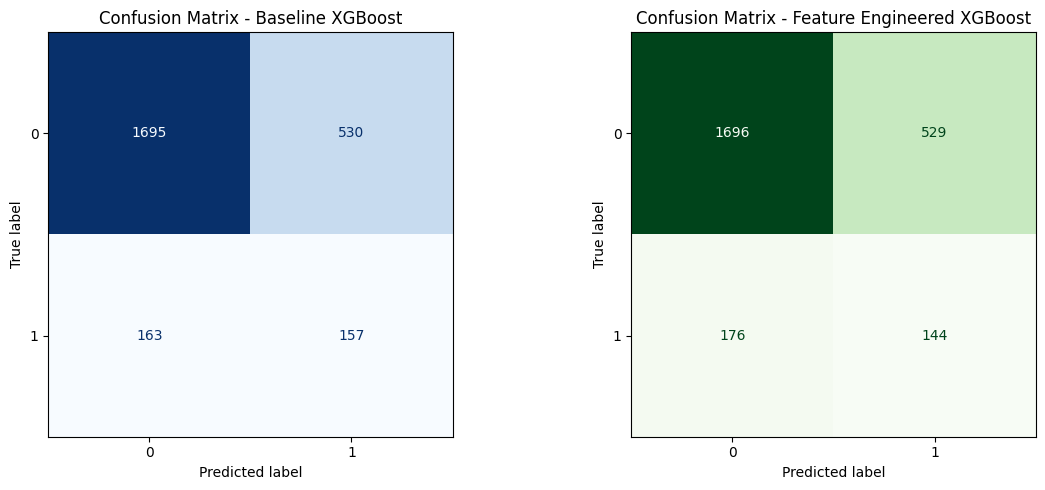

Báo cáo phân loại - Baseline XGBoost
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      2225
           1       0.23      0.49      0.31       320

    accuracy                           0.73      2545
   macro avg       0.57      0.63      0.57      2545
weighted avg       0.83      0.73      0.77      2545


Báo cáo phân loại - Feature Engineered XGBoost
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      2225
           1       0.21      0.45      0.29       320

    accuracy                           0.72      2545
   macro avg       0.56      0.61      0.56      2545
weighted avg       0.82      0.72      0.76      2545



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=baseline_cm)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Baseline XGBoost')
axes[0].grid(False)

disp2 = ConfusionMatrixDisplay(confusion_matrix=fe_cm)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Feature Engineered XGBoost')
axes[1].grid(False)

plt.tight_layout()
plt.show()

print('Báo cáo phân loại - Baseline XGBoost')
print(baseline_report)
print('\nBáo cáo phân loại - Feature Engineered XGBoost')
print(fe_report)

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    selected_pipe,
    X_train_best,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1,
)

cv_summary = pd.Series({
    'Mô_hình_được_chọn': selected_model_name,
    'CV_Accuracy_Mean': np.mean(cv_scores['test_accuracy']),
    'CV_Precision_Mean': np.mean(cv_scores['test_precision']),
    'CV_Recall_Mean': np.mean(cv_scores['test_recall']),
    'CV_F1_Mean': np.mean(cv_scores['test_f1']),
    'CV_ROC_AUC_Mean': np.mean(cv_scores['test_roc_auc']),
})

for metric in ['CV_Accuracy_Mean', 'CV_Precision_Mean', 'CV_Recall_Mean', 'CV_F1_Mean', 'CV_ROC_AUC_Mean']:
    cv_summary[metric] = round(float(cv_summary[metric]), 4)

cv_summary

Mô_hình_được_chọn    Baseline
CV_Accuracy_Mean       0.7439
CV_Precision_Mean      0.2406
CV_Recall_Mean         0.4802
CV_F1_Mean             0.3202
CV_ROC_AUC_Mean        0.7017
dtype: object

### Nhận xét output

- Dùng confusion matrix và classification report để phân tích FN/FP cho lớp bệnh.
- Dùng CV để kiểm tra tính ổn định trước khi chốt mô hình.

## 8. Chia dữ liệu train/test chuẩn
---

In [14]:
train_df = pd.concat([
    X_train_best.assign(**{TARGET_COL: y_train.values}),
    X_val_best.assign(**{TARGET_COL: y_val.values}),
], axis=0)
test_df = X_test_best.copy()
test_df[TARGET_COL] = y_test.values

train_path = BASE_DIR / 'train_diabetes_xgb.csv'
test_path = BASE_DIR / 'test_diabetes_xgb.csv'
train_df.to_csv(train_path, index=False, encoding='utf-8')
test_df.to_csv(test_path, index=False, encoding='utf-8')

print('Mô hình được chọn để export:', selected_model_name)
print('Train (train+val):', train_df.shape, 'Test holdout:', test_df.shape)
print('Đã lưu file train:', train_path)
print('Đã lưu file test:', test_path)

Mô hình được chọn để export: Baseline
Train (train+val): (10180, 45) Test holdout: (2545, 45)
Đã lưu file train: C:\Users\BSS GROUP\DATN_1\train_diabetes_xgb.csv
Đã lưu file test: C:\Users\BSS GROUP\DATN_1\test_diabetes_xgb.csv


### Nhận xét output

- Holdout test được giữ nguyên từ bước split ban đầu, không chia lại.
- File export riêng cho XGBoost để không ảnh hưởng luồng mô hình khác.

## 9. Lưu model và suy luận (trước tuning)
---

In [15]:
pre_tuned_model = selected_pipe
pre_tuned_model.fit(X_train_best, y_train)

model_path = ARTIFACT_DIR / 'diabetes_xgb_pipeline_pre_tuning.joblib'
meta_path = ARTIFACT_DIR / 'diabetes_xgb_model_metadata_pre_tuning.joblib'

joblib.dump(pre_tuned_model, model_path)
joblib.dump(
    {
        'model_name': f'{selected_model_name}_XGB_PreTuning',
        'target_col': TARGET_COL,
        'feature_list': X_train_best.columns.tolist(),
        'selected_model_by_val_f1': selected_model_name,
        'note': 'Demo inference trên validation sample',
    },
    meta_path,
)

print('Đã lưu model pre-tuning:', model_path.resolve())

X_new = X_val_best.head(5).copy()
pred = pre_tuned_model.predict(X_new)
prob = pre_tuned_model.predict_proba(X_new)[:, 1]
infer_df = X_new.copy()
infer_df['pred_label'] = pred
infer_df['pred_prob_diabetes'] = prob
infer_df.head()

Đã lưu model pre-tuning: C:\Users\BSS GROUP\DATN_1\artifacts\diabetes_xgb_pipeline_pre_tuning.joblib


,Gioi,Dan toc,Tinh chat cong viec,Trinh do van hoa,Thoi gian an cach bua toi,Tien xu bi tang huyet ap,Da dieu tri tang huyet ap bao gio chua,Bang an uong va luyen tap,DT_THA_DY,DT_THA_TY,...,BMI_class,Abdominal_Obese,Hypertension_class,WHR,WHR_class,khuvuc,tccv,Tuoi,pred_label,pred_prob_diabetes
2189,2,1,3,3,10,2,NaN,NaN,NaN,NaN,...,2,1,3.0,0.958333,4,2,1,60,1,0.582638
7655,1,1,4,2,11,2,NaN,NaN,NaN,NaN,...,3,0,1.0,1.012048,4,3,2,54,0,0.378626
11561,2,1,2,3,12,2,NaN,NaN,NaN,NaN,...,2,0,NaN,NaN,2,2,0,51,0,0.395511
1811,2,1,2,5,9,1,2.0,2.0,2.0,1.0,...,3,1,1.0,0.895833,4,2,0,66,1,0.627886
2460,2,1,2,3,9,2,NaN,NaN,NaN,NaN,...,2,0,NaN,0.872093,4,2,0,79,0,0.491604


### Nhận xét output

- Đã lưu model trước tuning để kiểm tra nhanh luồng inference.
- Bước 12 sẽ cập nhật artifact cuối cùng sau tuning.

## 10. Chia dữ liệu cho luồng đánh giá bổ sung
---

In [16]:
df_new = fe_data.copy()
if 'Diabetes_binary' in df_new.columns:
    target_col_aux = 'Diabetes_binary'
else:
    target_col_aux = TARGET_COL

X_aux_raw = df_new.drop(columns=[target_col_aux]).select_dtypes(include=['number']).copy()
y_aux = pd.to_numeric(df_new[target_col_aux], errors='coerce').fillna(0).astype(int)

X_train_aux, X_test_aux, y_train_aux, y_test_aux = train_test_split(
    X_aux_raw, y_aux, test_size=0.3, random_state=RANDOM_STATE, stratify=y_aux
)

train_medians = X_train_aux.median(numeric_only=True)
X_train_aux = X_train_aux.fillna(train_medians)
X_test_aux = X_test_aux.fillna(train_medians)

print('X_train_aux:', X_train_aux.shape, 'X_test_aux:', X_test_aux.shape)

X_train_aux: (8907, 48) X_test_aux: (3818, 48)


### Nhận xét output

- Luồng phụ được split trước và fill missing theo thống kê train để tránh leakage.
- Luồng này dùng để đối chiếu độ ổn định, không thay thế kết luận luồng chính.

## 11. Bảng so sánh metric Train/Test
---

In [17]:
scale_aux = get_scale_pos_weight(y_train_aux)
aux_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_aux,
    n_jobs=-1
)
aux_model.fit(X_train_aux, y_train_aux)

y_train_pred_aux = aux_model.predict(X_train_aux)
y_test_pred_aux = aux_model.predict(X_test_aux)

comparison_aux = pd.DataFrame({
    'Tập': ['Test', 'Train'],
    'Recall': [recall_score(y_test_aux, y_test_pred_aux), recall_score(y_train_aux, y_train_pred_aux)],
    'Precision': [precision_score(y_test_aux, y_test_pred_aux, zero_division=0), precision_score(y_train_aux, y_train_pred_aux, zero_division=0)],
    'F1 Score': [f1_score(y_test_aux, y_test_pred_aux, zero_division=0), f1_score(y_train_aux, y_train_pred_aux, zero_division=0)],
    'Accuracy': [accuracy_score(y_test_aux, y_test_pred_aux), accuracy_score(y_train_aux, y_train_pred_aux)],
})
comparison_aux.round(4)

,Tập,Recall,Precision,F1 Score,Accuracy
0,Test,0.5188,0.2107,0.2996,0.6951
1,Train,0.8705,0.3596,0.5090,0.7888


### Nhận xét output

- So sánh Train/Test giúp nhận biết mức độ overfitting của luồng phụ.
- Nếu gap lớn, cần tăng regularization hoặc giảm độ phức tạp mô hình.

## 12. Tinh chỉnh siêu tham số
---

In [18]:
X_train_tune = X_train_best.copy()
X_val_tune = X_val_best.copy()
X_test_tune = X_test_best.copy()

pipe_tune = build_xgb_pipeline(X_train_tune, y_train)

param_grid = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [3, 4, 6],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.8, 0.9],
    'model__colsample_bytree': [0.6, 0.8],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_lambda': [1.0, 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe_tune, param_grid=param_grid, scoring='f1', cv=cv, n_jobs=-1, refit=True)
grid.fit(X_train_tune, y_train)

best_tuned_pipe = grid.best_estimator_
tuned_val_metrics, tuned_val_report, tuned_val_cm = evaluate_model(
    best_tuned_pipe, X_train_tune, X_val_tune, y_train, y_val
)

X_trainval_tune = pd.concat([X_train_tune, X_val_tune], axis=0)
y_trainval_tune = pd.concat([y_train, y_val], axis=0)

final_pipe = build_xgb_pipeline(X_trainval_tune, y_trainval_tune)
final_pipe.set_params(**grid.best_params_)
final_test_metrics, tuned_report, tuned_cm = evaluate_model(
    final_pipe, X_trainval_tune, X_test_tune, y_trainval_tune, y_test
)

final_model_path = ARTIFACT_DIR / 'diabetes_xgb_pipeline.joblib'
final_meta_path = ARTIFACT_DIR / 'diabetes_xgb_model_metadata.joblib'

joblib.dump(final_pipe, final_model_path)
joblib.dump(
    {
        'model_name': f'{selected_model_name}_XGB_Tuned',
        'target_col': TARGET_COL,
        'feature_list': X_trainval_tune.columns.tolist(),
        'selected_model_by_val_f1': selected_model_name,
        'best_cv_f1': float(grid.best_score_),
        'best_params': grid.best_params_,
        'validation_metrics': tuned_val_metrics,
        'test_metrics': final_test_metrics,
    },
    final_meta_path,
)

print('Mô hình được chọn:', selected_model_name)
print('Best CV F1:', round(grid.best_score_, 4))
print('Tham số tốt nhất:', grid.best_params_)
print('Metric validation:', pd.Series(tuned_val_metrics).round(4).to_dict())
print('Đã cập nhật artifact cuối cùng:', final_model_path.resolve())
pd.Series(final_test_metrics).round(4)

Mô hình được chọn: Baseline
Best CV F1: 0.3398
Tham số tốt nhất: {'model__colsample_bytree': 0.6, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__min_child_weight': 5, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}
Metric validation: {'Accuracy': 0.679, 'Precision': 0.2121, 'Recall': 0.5719, 'F1': 0.3094, 'ROC_AUC': 0.6987}
Đã cập nhật artifact cuối cùng: C:\Users\BSS GROUP\DATN_1\artifacts\diabetes_xgb_pipeline.joblib


Accuracy     0.6739
Precision    0.2135
Recall       0.5938
F1           0.3140
ROC_AUC      0.7013
dtype: float64

### Nhận xét output

- Tuning được chạy trên model đã chọn ở Bước 6, tối ưu theo F1.
- Sau đó refit bằng Train+Validation và đánh giá Test một lần duy nhất.
- Bạn ghi lại các metric thực tế sau khi chạy để hoàn thiện phần báo cáo.

## 12b. Tối ưu ngưỡng dự đoán
---

Mục tiêu: quét nhiều ngưỡng xác suất để chọn ngưỡng phù hợp hơn cho bài toán sàng lọc lớp bệnh (1).

In [20]:
from sklearn.metrics import precision_recall_curve

# Dùng mô hình tuned để quét ngưỡng trên validation
val_prob = final_pipe.predict_proba(X_val_tune)[:, 1]
threshold_grid = np.arange(0.1, 0.91, 0.02)

threshold_rows = []
for th in threshold_grid:
    val_pred = (val_prob >= th).astype(int)
    threshold_rows.append({
        'Threshold': round(float(th), 2),
        'Precision_Val': precision_score(y_val, val_pred, zero_division=0),
        'Recall_Val': recall_score(y_val, val_pred, zero_division=0),
        'F1_Val': f1_score(y_val, val_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_f1_row = threshold_df.sort_values(['F1_Val', 'Recall_Val'], ascending=False).iloc[0]

# Ngưỡng theo mục tiêu recall >= 0.7 (nếu có)
recall_target = 0.70
candidate_recall_rows = threshold_df[threshold_df['Recall_Val'] >= recall_target]
if len(candidate_recall_rows) > 0:
    best_recall_target_row = candidate_recall_rows.sort_values(['F1_Val', 'Precision_Val'], ascending=False).iloc[0]
else:
    best_recall_target_row = None

print('Ngưỡng tốt nhất theo F1 validation:')
print(best_f1_row.round(4).to_dict())

if best_recall_target_row is not None:
    print('\nNgưỡng tốt nhất với ràng buộc Recall >= 0.70:')
    print(best_recall_target_row.round(4).to_dict())
else:
    print('\nKhông có ngưỡng nào đạt Recall >= 0.70 trên validation.')

threshold_df.sort_values('F1_Val', ascending=False).head(10)

Ngưỡng tốt nhất theo F1 validation:
{'Threshold': 0.58, 'Precision_Val': 0.3494, 'Recall_Val': 0.6562, 'F1_Val': 0.456}

Ngưỡng tốt nhất với ràng buộc Recall >= 0.70:
{'Threshold': 0.54, 'Precision_Val': 0.3109, 'Recall_Val': 0.7375, 'F1_Val': 0.4374}


,Threshold,Precision_Val,Recall_Val,F1_Val
24,0.58,0.349418,0.656250,0.456026
25,0.60,0.366279,0.590625,0.452153
27,0.64,0.412073,0.490625,0.447932
23,0.56,0.327407,0.690625,0.444221
26,0.62,0.378685,0.521875,0.438896
22,0.54,0.310935,0.737500,0.437442
28,0.66,0.440514,0.428125,0.434231
21,0.52,0.298225,0.787500,0.432618
20,0.50,0.286638,0.831250,0.426282
19,0.48,0.271739,0.859375,0.412913


In [21]:
# Đánh giá trên holdout test theo 2 chiến lược ngưỡng
test_prob = final_pipe.predict_proba(X_test_tune)[:, 1]

def eval_threshold(th):
    y_pred_th = (test_prob >= th).astype(int)
    return {
        'Threshold': float(th),
        'Accuracy': accuracy_score(y_test, y_pred_th),
        'Precision': precision_score(y_test, y_pred_th, zero_division=0),
        'Recall': recall_score(y_test, y_pred_th, zero_division=0),
        'F1': f1_score(y_test, y_pred_th, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, test_prob),
        'ConfusionMatrix': confusion_matrix(y_test, y_pred_th),
    }

default_metrics = eval_threshold(0.5)
best_f1_metrics = eval_threshold(best_f1_row['Threshold'])

report_rows = [
    {k: v for k, v in default_metrics.items() if k != 'ConfusionMatrix'},
    {k: v for k, v in best_f1_metrics.items() if k != 'ConfusionMatrix'},
]

if best_recall_target_row is not None:
    best_recall_metrics = eval_threshold(best_recall_target_row['Threshold'])
    report_rows.append({k: v for k, v in best_recall_metrics.items() if k != 'ConfusionMatrix'})
else:
    best_recall_metrics = None

threshold_compare = pd.DataFrame(report_rows)
threshold_compare['Chiến lược'] = ['Default_0.50', 'Best_F1_Val'] + (['Best_Recall>=0.70_Val'] if best_recall_metrics else [])

cols_order = ['Chiến lược', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
threshold_compare = threshold_compare[cols_order]
threshold_compare.round(4)

,Chiến lược,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Default_0.50,0.50,0.6739,0.2135,0.5938,0.3140,0.7013
1,Best_F1_Val,0.58,0.7639,0.2459,0.4250,0.3116,0.7013
2,Best_Recall>=0.70_Val,0.54,0.7191,0.2283,0.5188,0.3171,0.7013


### Nhận xét output (tối ưu ngưỡng)

- Ngưỡng mặc định 0.50 cho Test: Precision **0.2135**, Recall **0.5938**, F1 **0.3140**.
- Ngưỡng tối ưu theo F1 trên Validation (0.58) làm Accuracy tăng mạnh (**0.7639**) nhưng Recall giảm (**0.4250**), nên F1 Test không cải thiện (**0.3116**).
- Ngưỡng tối ưu theo ràng buộc Recall >= 0.70 trên Validation (0.54) cho cân bằng tốt hơn trên Test: Precision **0.2283**, Recall **0.5188**, F1 **0.3171**.
- Kết luận: với mục tiêu sàng lọc, ngưỡng **0.54** hợp lý hơn 0.50 vì tăng F1 và giữ Recall ở mức khá.

## 13. Train XGBoost cho luồng đánh giá bổ sung
---

In [19]:
scale_aux_final = get_scale_pos_weight(y_train_aux)
model_aux_final = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_aux_final,
    n_jobs=-1
)
model_aux_final.fit(X_train_aux, y_train_aux)

y_pred_aux_final = model_aux_final.predict(X_test_aux)
y_prob_aux_final = model_aux_final.predict_proba(X_test_aux)[:, 1]

aux_final_metrics = {
    'Accuracy': accuracy_score(y_test_aux, y_pred_aux_final),
    'Precision': precision_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'Recall': recall_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'F1': f1_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test_aux, y_prob_aux_final),
}

print('Metric luồng bổ sung:')
print(pd.Series(aux_final_metrics).round(4).to_string())
print('\nBáo cáo phân loại:')
print(classification_report(y_test_aux, y_pred_aux_final))

Metric luồng bổ sung:
Accuracy     0.7347
Precision    0.2283
Recall       0.4667
F1           0.3066
ROC_AUC      0.6712

Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84      3338
           1       0.23      0.47      0.31       480

    accuracy                           0.73      3818
   macro avg       0.57      0.62      0.57      3818
weighted avg       0.82      0.73      0.77      3818



### Nhận xét output

- Tổng hợp metric của luồng phụ để đối chiếu với luồng chính.
- Tập trung đánh giá lớp 1 (bệnh) qua Recall, F1 và số FN.

## Tổng kết

### Mục tiêu giải trình

- Pipeline XGBoost được xây dựng tương tự Logistic và Random Forest để dễ so sánh và bảo vệ.
- Quy trình giữ nguyên nguyên tắc chống leakage và chỉ dùng holdout test một lần cuối.

### Ý nghĩa khoa học và kỹ thuật

- Model được chọn theo tiêu chí cân bằng giữa F1 validation và train-validation gap.
- Metadata lưu đầy đủ best params, validation metrics và test metrics để truy vết.

### Hướng cải thiện tiếp theo

- Tối ưu ngưỡng phân loại theo mục tiêu recall lớp bệnh.
- So sánh thêm LightGBM hoặc CatBoost trên cùng tập feature đã lọc leakage.